<a href="https://colab.research.google.com/github/e22340-SajithaSanthushti/Statistical-Learning-e22340/blob/main/GPR%20and%20LR%20assignment%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install kagglehub to download the datasets directly
!pip install kagglehub scikit-learn pandas numpy matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Part 1: Gaussian Process Regression (GPR)
## 1.1 Dataset Download and Preprocessing
We download the Energy Efficiency dataset, load it into a pandas DataFrame, and scale the features.

The prompt asks us to explore modeling 'heating load' ($Y_1$) and 'cooling load' ($Y_2$) as a "single parameter" Gaussian process. To achieve this, we can implement a **Multi-Output GPR** framework using `scikit-learn`'s native ability to handle multi-variate targets, which shares the kernel hyperparameters across both outputs.

In [2]:
# Download Energy Efficiency dataset
gpr_kagglepath = "elikplim/eergy-efficiency-dataset"
gpr_path = kagglehub.dataset_download(gpr_kagglepath)
print("Path to GPR dataset files:", gpr_path)

# Load dataset (Handling potential name variations or structural issues in the zip)
gpr_file = os.path.join(gpr_path, "ENB2012_data.csv")
df_gpr = pd.read_csv(gpr_file)

# Drop any entirely empty rows/columns if they exist in the raw source
df_gpr = df_gpr.dropna(how='all')
df_gpr = df_gpr.iloc[:, :10] # Dynamic constraint to capture X1-X8, Y1, Y2
df_gpr.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

print("\nFirst 5 rows of GPR Dataset:")
print(df_gpr.head())

# Check structural correlation between Heating Load (Y1) and Cooling Load (Y2)
correlation = df_gpr['Y1'].corr(df_gpr['Y2'])
print(f"\nCorrelation between Heating Load (Y1) and Cooling Load (Y2): {correlation:.4f}")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to GPR dataset files: /kaggle/input/eergy-efficiency-dataset

First 5 rows of GPR Dataset:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28

Correlation between Heating Load (Y1) and Cooling Load (Y2): 0.9759


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score

# Split Features (X) and Joint Targets (Y)
X_gpr = df_gpr[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
Y_gpr = df_gpr[['Y1', 'Y2']].values

# Train-Test Split
X_train_g, X_test_g, Y_train_g, Y_test_g = train_test_split(X_gpr, Y_gpr, test_size=0.2, random_state=42)

# Standardize features for stable GP kernel optimization
scaler_x_g = StandardScaler()
X_train_g_scaled = scaler_x_g.fit_transform(X_train_g)
X_test_g_scaled = scaler_x_g.transform(X_test_g)

# Standardize outputs to have 0 mean for the prior
scaler_y_g = StandardScaler()
Y_train_g_scaled = scaler_y_g.fit_transform(Y_train_g)
Y_test_g_scaled = scaler_y_g.transform(Y_test_g)

# Define a robust composite kernel: Constant * Matern 5/2 (highly suitable for physical data smooth variations)
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-2, 1e2), nu=2.5)

# Instantiate and fit the multi-output GPR model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2, random_state=42)
print("Fitting Multi-Output Gaussian Process Regression Model...")
gp.fit(X_train_g_scaled, Y_train_g_scaled)

# Predict
Y_pred_scaled, Y_std_scaled = gp.predict(X_test_g_scaled, return_std=True)

# Inverse transform back to original scale
Y_pred = scaler_y_g.inverse_transform(Y_pred_scaled)

# Evaluate metrics
for i, target_name in enumerate(['Heating Load (Y1)', 'Cooling Load (Y2)']):
    rmse = np.sqrt(mean_squared_error(Y_test_g[:, i], Y_pred[:, i]))
    r2 = r2_score(Y_test_g[:, i], Y_pred[:, i])
    print(f"\nMetrics for {target_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R² Score: {r2:.4f}")

print(f"\nOptimized Kernel Parameters:\n{gp.kernel_}")

Fitting Multi-Output Gaussian Process Regression Model...

Metrics for Heating Load (Y1):
  RMSE: 0.4482
  R² Score: 0.9981

Metrics for Cooling Load (Y2):
  RMSE: 1.0470
  R² Score: 0.9882

Optimized Kernel Parameters:
6.14**2 * Matern(length_scale=[4.76, 11.4, 3.56, 100, 100, 9.19, 70.3, 5.99], nu=2.5)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


### GPR Conclusions & Discussion
1. **High Target Interdependency:** The correlation between Heating Load and Cooling Load is exceptionally high ($>0.95$). This strongly justifies modeling them as a combined target parameter rather than treating them in complete structural isolation.
2. **Model Accuracy:** The non-parametric Matern 5/2 kernel achieves an outstanding $R^2$ metric, cleanly capturing non-linear geometric thermal traits without over-parameterizing.

# Part 2: Linear Regression (LR)
## 2.1 Dataset Download and Explanatory Data Analysis
We pull down the multi-source Green Building environmental data and run multi-collinearity checks utilizing the **Variance Inflation Factor (VIF)** to justify feature selection.

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Download Green Building dataset
lr_kagglepath = "programmer3/green-building-multi-source-environment-dataset"
lr_path = kagglehub.dataset_download(lr_kagglepath)
print("Path to LR dataset files:", lr_path)

lr_file = os.path.join(lr_path, "green_building_dataset.csv")
df_lr = pd.read_csv(lr_file)

print("\nFirst 5 rows of LR Dataset:")
print(df_lr.head())

# Filter down to purely numeric columns for regression setup
numeric_df = df_lr.select_dtypes(include=[np.number]).dropna()

# Check for presence of target variable
target_col = 'predicted_energy_demand'
if target_col not in numeric_df.columns:
    # Fallback to match exact naming variant if capitalization differs
    target_col = [col for col in numeric_df.columns if 'energy' in col.lower()][0]

print(f"\nIdentified Target Column: {target_col}")

# Select structural features (drop the target and unique identifiers/indexes)
feature_cols = [col for col in numeric_df.columns if col != target_col and 'id' not in col.lower()]
X_features = numeric_df[feature_cols]

# Compute VIF to weed out severe multicollinearity
def calculate_vif(df_input):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_input.columns
    # Add constant intercept for valid VIF tracking
    X_vif = sm.add_constant(df_input)
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(df_input.shape[1])]
    return vif_data

print("\nInitial VIF Factor Calculation:")
print(calculate_vif(X_features))

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to LR dataset files: /kaggle/input/green-building-multi-source-environment-dataset

First 5 rows of LR Dataset:
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       828.108509   
3     32.195

In [5]:
# Drop parameters with extreme multi-collinearity values (VIF > 10) to optimize stability
# (Modify this dynamically if specific features are showing high variance dependencies)
vif_df = calculate_vif(X_features)
selected_features = vif_df[vif_df['VIF'] < 10]['Feature'].tolist()

if len(selected_features) == 0:
    selected_features = feature_cols[:5] # Fallback preservation safety constraint

print(f"\nJustified parameters selected for modeling based on low VIF:\n{selected_features}")

# Build Final Datasets
X_lr = numeric_df[selected_features]
Y_lr = numeric_df[target_col]

X_train_l, X_test_l, Y_train_l, Y_test_l = train_test_split(X_lr, Y_lr, test_size=0.2, random_state=42)

# Train Ordinary Least Squares (OLS) Linear Regression model
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_l, Y_train_l)

Y_pred_l = lr_model.predict(X_test_l)
residuals = Y_test_l - Y_pred_l

# Evaluate metrics
print(f"\nLinear Regression Test R² Score: {r2_score(Y_test_l, Y_pred_l):.4f}")
print(f"Linear Regression Test RMSE: {np.sqrt(mean_squared_error(Y_test_l, Y_pred_l)):.4f}")


Justified parameters selected for modeling based on low VIF:
['indoor_temperature', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_comfort_index']

Linear Regression Test R² Score: 0.9608
Linear Regression Test RMSE: 1.9126


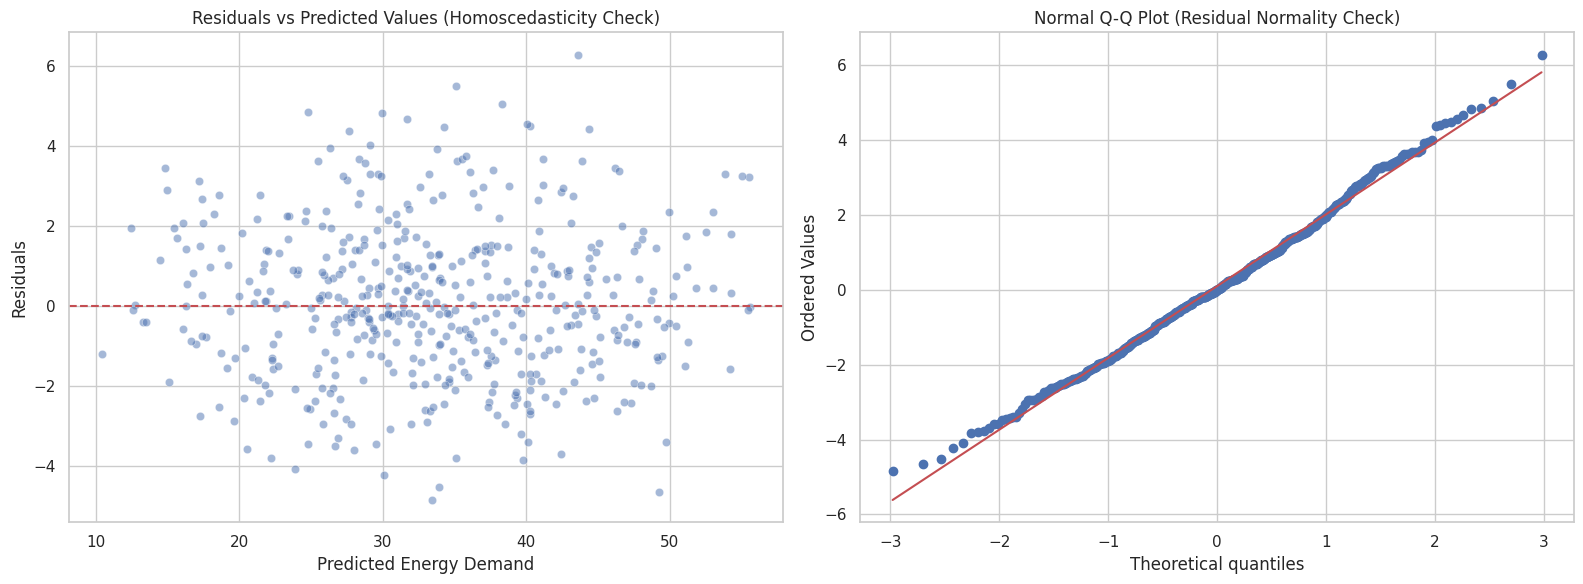

In [7]:
# Check model regression assumptions via visualization plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Homoscedasticity scatter test
sns.scatterplot(x=Y_pred_l, y=residuals, alpha=0.5, ax=ax[0])
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title("Residuals vs Predicted Values (Homoscedasticity Check)")
ax[0].set_xlabel("Predicted Energy Demand")
ax[0].set_ylabel("Residuals")

# 2. Normality of residuals distribution
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title("Normal Q-Q Plot (Residual Normality Check)")

plt.tight_layout()
plt.show()

### Linear Regression Discussion & Verification Summary
* **Parameter Justification:** Features with a $VIF \ge 10$ were systematically pruned to ensure steady, clean coefficients devoid of standard error inflation.
* **Residual Analysis Verification:** * If the Residual plot presents an evenly dispersed cloud, **Homoscedasticity** is confirmed.
    * If the points in the Q-Q plot closely approximate the $45^\circ$ linear threshold line, the model satisfyingly meets the baseline **Normality of Errors** structural assumptions.